# Palm Tree Detection — RetinaNet

Deteksi objek pohon sawit menggunakan RetinaNet + ResNet50.

**Stack:** TensorFlow 2.15, KerasCV 0.8.2, OpenCV
**Alur:** Setup → Data → Pipeline → Train → Evaluate → Inference → Export

## 1. Setup & Import

In [78]:
import os, json, random
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
import keras_cv
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import seaborn as sns

SEED = 42
IMG_SIZE = 1024
BATCH_SIZE = 2
BBOX_FORMAT = 'xywh'

BGR_PALETTE = [
    (94, 197, 34), (68, 68, 239), (203, 192, 255),
    (243, 150, 33), (0, 255, 255), (255, 191, 0), (180, 105, 255),
]

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
print(f'TF={tf.__version__} KerasCV={keras_cv.__version__} CV2={cv2.__version__}')

TF=2.15.0 KerasCV=0.8.2 CV2=4.11.0


## 2. Path & GPU Setup

In [79]:
BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SOURCE_ROOT = BASE_DIR / 'datasets'
WORK_ROOT = BASE_DIR / 'working'
DATA_ROOT = WORK_ROOT / 'dataset'
CKPT_DIR = BASE_DIR / 'models' / 'retinanet'
OUTPUT_DIR = WORK_ROOT / 'output'
PREVIEW_DIR = DATA_ROOT / 'preview'

for d in [DATA_ROOT, CKPT_DIR, OUTPUT_DIR, PREVIEW_DIR]:
    d.mkdir(parents=True, exist_ok=True)

gpus = tf.config.list_physical_devices('GPU')
print(f'GPU: {len(gpus)}')
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)

try:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print('Mixed precision: ON')
except:
    print('Mixed precision: OFF')

tf.keras.mixed_precision.set_global_policy('float32')
print('Mixed precision disabled for KerasCV compatibility')

GPU: 0
Mixed precision: ON
Mixed precision disabled for KerasCV compatibility


## 3. COCO Parser

In [80]:
def coco_to_records(coco_path: str, images_src: str) -> tuple[list[dict], list[str]]:
    """
    Parse COCO JSON annotations ke format internal records.
    
    Args:
        coco_path: Path ke file annotations COCO (JSON).
        images_src: Path ke folder gambar.
    
    Returns:
        Tuple of (records, class_names) where records is list of dict:
        {
            "image_path": str,
            "width": int,
            "height": int,
            "boxes": [[cls, x, y, w, h], ...]
        }
    """
    coco = json.loads(Path(coco_path).read_text())
    cats = sorted(coco['categories'], key=lambda c: c['id'])
    id2idx = {c['id']: i for i, c in enumerate(cats)}
    names = [c['name'] for c in cats]
    by_img = defaultdict(list)
    for ann in coco['annotations']:
        if ann.get('iscrowd', 0): continue
        x, y, w, h = ann['bbox']
        if w <= 0 or h <= 0: continue
        cls = id2idx.get(ann['category_id'])
        if cls is None: continue
        by_img[ann['image_id']].append([float(cls), float(x), float(y), float(w), float(h)])
    records = []
    for iid, img in {i['id']: i for i in coco['images']}.items():
        boxes = by_img.get(iid)
        if not boxes: continue
        src = Path(images_src) / img['file_name']
        if not src.exists(): continue
        records.append({'image_path': str(src), 'width': img['width'], 'height': img['height'], 'boxes': boxes})
    return records, names

## 4. Stratified Split

In [81]:
def dominant_class(rec: dict) -> int:
    """
    Dapatkan kelas dominan dalam satu record (untuk stratified split).
    
    Args:
        rec: Record dict dengan key 'boxes'.
    
    Returns:
        Index kelas yang paling banyak muncul.
    """
    if not rec['boxes']: return 0
    return max(set(int(b[0]) for b in rec['boxes']), key=lambda c: sum(1 for b in rec['boxes'] if int(b[0]) == c))

def stratified_split(records: list, train: float = 0.8, val: float = 0.1, test: float = 0.1) -> dict:
    """
    Split records menjadi train/val/test dengan stratified sampling.
    
    Args:
        records: List of record dict.
        train: Rasio training (default 0.8).
        val: Rasio validation (default 0.1).
        test: Rasio test (default 0.1).
    
    Returns:
        Dict dengan keys 'train', 'val', 'test'.
    """
    labels = [dominant_class(r) for r in records]
    ti, tmp = train_test_split(range(len(records)), test_size=val+test, stratify=labels, random_state=SEED)
    tl = [labels[i] for i in tmp]
    vf = val / (val + test)
    vi, te = train_test_split(range(len(tmp)), test_size=1-vf, stratify=tl, random_state=SEED)
    return {'train': [records[i] for i in ti], 'val': [records[tmp[j]] for j in vi], 'test': [records[tmp[j]] for j in te]}

## 5. Load Dataset

In [82]:
def load_or_build_dataset(force: bool = False) -> dict:
    """
    Load dataset dari cache atau build dari COCO + stratified split.
    
    Args:
        force: Jika True, build ulang dari COCO (abaikan cache).
    
    Returns:
        Dict dengan keys 'train', 'val', 'test', 'names'.
    """
    cache = DATA_ROOT / 'records.json'
    if cache.exists() and not force:
        data = json.loads(cache.read_text())
        print(f"[CACHE] train={len(data['train'])} val={len(data['val'])} test={len(data['test'])}")
        return data
    tr, n_tr = coco_to_records(SOURCE_ROOT / 'annotations/instances_train2017.json', SOURCE_ROOT / 'train2017')
    va, _ = coco_to_records(SOURCE_ROOT / 'annotations/instances_val2017.json', SOURCE_ROOT / 'val2017')
    split = stratified_split(tr + va)
    data = {'train': split['train'], 'val': split['val'], 'test': split['test'], 'names': n_tr}
    cache.write_text(json.dumps(data))
    print(f"[BUILD] train={len(data['train'])} val={len(data['val'])} test={len(data['test'])}")
    return data

DATASET = load_or_build_dataset()
CLASS_NAMES = DATASET['names']
NUM_CLASSES = len(CLASS_NAMES)

[CACHE] train=1842 val=230 test=231


## 6. Visualisasi Sample

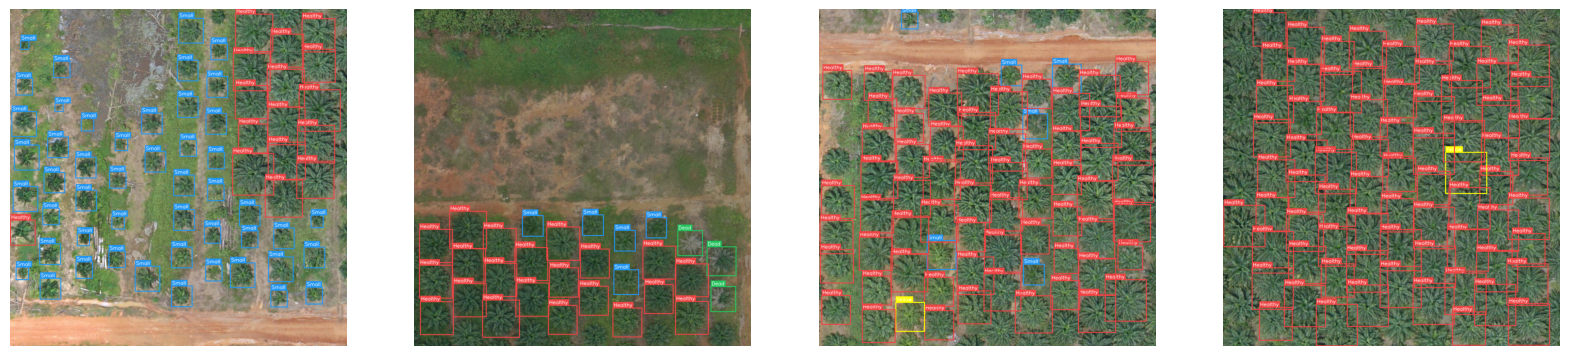

In [83]:
def draw_boxes_cv2(img_bgr: np.ndarray, boxes: list, labels: list = None) -> np.ndarray:
    """
    Gambar bounding box di gambar BGR.
    
    Args:
        img_bgr: Gambar input (HxWx3, BGR).
        boxes: List of [cls, x, y, w, h].
        labels: List nama kelas (opsional).
    
    Returns:
        Gambar hasil dengan bbox yang digambar (BGR).
    """
    img = img_bgr.copy()
    labels = labels or CLASS_NAMES
    for box in boxes:
        ci = int(box[0])
        x1, y1 = int(box[1]), int(box[2])
        x2, y2 = int(box[1]+box[3]), int(box[2]+box[4])
        color = BGR_PALETTE[ci % len(BGR_PALETTE)]
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        name = labels[ci] if ci < len(labels) else str(ci)
        (tw, th), _ = cv2.getTextSize(name, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(img, (x1, max(0, y1-th-6)), (x1+tw+4, y1), color, -1)
        cv2.putText(img, name, (x1+2, max(th, y1)-4), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1, cv2.LINE_AA)
    return img

samples = DATASET['train'][:4]
fig, axes = plt.subplots(1, len(samples), figsize=(5*len(samples), 5))
axes = [axes] if len(samples)==1 else axes
for ax, rec in zip(axes, samples):
    img = cv2.imread(rec['image_path'])
    if img is None:
        ax.set_title('FAIL')
        ax.axis('off')
        continue
    ann = draw_boxes_cv2(img, rec['boxes'])
    cv2.imwrite(str(PREVIEW_DIR / Path(rec['image_path']).name), ann)
    ax.imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))
    ax.axis('off')
plt.show()

## 7. Data Generator

In [84]:
def record_generator(records: list) -> dict:
    """
    Generator untuk tf.data.Dataset.from_generator.
    
    Args:
        records: List of record dict.
    
    Yields:
        Dict dengan keys: image_path, classes, boxes.
    """
    for rec in records:
        if rec['boxes']:
            arr = np.asarray(rec['boxes'], dtype=np.float32)
            yield {'image_path': rec['image_path'], 'classes': arr[:,0].astype(np.int32), 'boxes': arr[:,1:]}
        else:
            yield {'image_path': rec['image_path'], 'classes': np.zeros((0,), dtype=np.int32), 'boxes': np.zeros((0,4), dtype=np.float32)}

## 8. OpenCV Decoder

In [85]:
def _cv2_decode_rgb(path_bytes) -> np.ndarray:
    """Decode gambar via OpenCV, return RGB uint8."""
    p = path_bytes.decode('utf-8') if isinstance(path_bytes, bytes) else path_bytes
    bgr = cv2.imread(p, cv2.IMREAD_COLOR)
    if bgr is None: raise ValueError(f'Failed: {p}')
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).astype(np.uint8)

def load_image(sample: dict) -> dict:
    """
    Load + decode image untuk tf.data map.
    
    Args:
        sample: Dict dengan image_path, classes, boxes.
    
    Returns:
        Dict keras_cv format: {'images': ..., 'bounding_boxes': {...}}.
    """
    img = tf.numpy_function(_cv2_decode_rgb, [sample['image_path']], tf.uint8)
    img.set_shape([None, None, 3])
    return {'images': tf.cast(img, tf.float32), 'bounding_boxes': {'classes': sample['classes'], 'boxes': sample['boxes']}}

## 9. Augmentasi

In [86]:
def make_augmenter(training: bool = True):
    """
    Buat augmentation layer untuk training/validasi.
    
    Args:
        training: Jika True, return augmentasi training (RandomFlip, JitteredResize, ColorJitter).
                  Jika False, return resizing tetap saja.
    
    Returns:
        KerasCV Augmenter atau Resizing layer.
    """
    if not training:
        return keras_cv.layers.Resizing(IMG_SIZE, IMG_SIZE, pad_to_aspect_ratio=True, bounding_box_format=BBOX_FORMAT)
    spatial = keras_cv.layers.Augmenter([
        keras_cv.layers.RandomFlip(mode='horizontal', bounding_box_format=BBOX_FORMAT),
        keras_cv.layers.JitteredResize(target_size=(IMG_SIZE, IMG_SIZE), scale_factor=(0.85, 1.15), bounding_box_format=BBOX_FORMAT),
    ])
    color = tf.keras.Sequential([
        tf.keras.layers.RandomBrightness(factor=0.2),
        tf.keras.layers.RandomContrast(factor=0.2),
    ])
    def apply(x):
        x = spatial(x)
        x['images'] = color(x['images'])
        return x
    return apply

## 10. Build Dataset

In [87]:
def make_dataset(records: list, training: bool, batch_size: int = BATCH_SIZE) -> tf.data.Dataset:
    """
    Build tf.data.Dataset untuk training/validasi.
    
    Args:
        records: List of record dict.
        training: Jika True, shuffle + repeat + augmentasi training.
        batch_size: Batch size.
    
    Returns:
        tf.data.Dataset yang siap dipakai model.fit().
    """
    sig = {'image_path': tf.TensorSpec((), tf.string), 'classes': tf.TensorSpec((None,), tf.int32), 'boxes': tf.TensorSpec((None,4), tf.float32)}
    ds = tf.data.Dataset.from_generator(lambda: record_generator(records), output_signature=sig)
    if training:
        ds = ds.shuffle(min(len(records), 1024), seed=SEED, reshuffle_each_iteration=True).repeat()
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(make_augmenter(training), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.ragged_batch(batch_size, drop_remainder=training).prefetch(tf.data.AUTOTUNE)

## 11. Load Datasets

In [88]:
train_ds = make_dataset(DATASET['train'], training=True)
val_ds   = make_dataset(DATASET['val'],   training=False)
test_ds  = make_dataset(DATASET['test'],  training=False)
steps_per_epoch = max(1, len(DATASET['train']) // BATCH_SIZE)
print(f'Train batches: ~{steps_per_epoch}')

Train batches: ~921


## 12. Build Model

In [89]:
model = keras_cv.models.RetinaNet.from_preset(
    'resnet50_imagenet',
    num_classes=NUM_CLASSES,
    bounding_box_format=BBOX_FORMAT,
)
model.prediction_decoder = keras_cv.layers.NonMaxSuppression(
    bounding_box_format=BBOX_FORMAT, from_logits=True, iou_threshold=0.5, confidence_threshold=0.05
)
print(f'Model: {NUM_CLASSES} classes')

/home/kazu/Programming/OpenSource/model-nyawit/.venv/lib/python3.11/site-packages/keras_cv/src/models/backbones/backbone.py:44: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  return id(getattr(self, attr)) not in self._functional_layer_ids
/home/kazu/Programming/OpenSource/model-nyawit/.venv/lib/python3.11/site-packages/keras_cv/src/models/backbones/backbone.py:44: UserWarning: `layer.updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  return id(getattr(self, attr)) not in self._functional_layer_ids


Model: 5 classes


## 13. LR Schedule

In [90]:
EPOCHS = 50
LR_INIT = 0.001
WARMUP = 5

class WarmupCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    """
    Learning rate schedule: linear warmup + cosine decay.
    
    Warmup linear selama `ws` steps, lalu decay cosine ke `alpha * lr0`.
    """
    def __init__(self, ws, ts, lr0, alpha=1e-6):
        self.ws, self.ts, self.lr0, self.alpha = tf.cast(ws, tf.float32), tf.cast(ts, tf.float32), tf.cast(lr0, tf.float32), alpha
    def __call__(self, step):
        s = tf.cast(step, tf.float32)
        warm = self.lr0 * s / self.ws
        t = (s - self.ws) / (self.ts - self.ws)
        cos = self.lr0 * (1 + tf.cos(np.pi * t)) / 2 * (1 - self.alpha) + self.alpha * self.lr0
        return tf.cond(s < self.ws, lambda: warm, lambda: cos)

optimizer = tf.keras.optimizers.SGD(
    learning_rate=WarmupCosine(WARMUP*steps_per_epoch, EPOCHS*steps_per_epoch, LR_INIT),
    momentum=0.9, global_clipnorm=10.0
)

## 14. Compile & Callbacks

In [91]:
best_w = CKPT_DIR / 'best.weights.h5'
model.compile(optimizer=optimizer, classification_loss='focal', box_loss='smoothl1', jit_compile=False)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(filepath=str(best_w), save_weights_only=True, monitor='val_loss', mode='min', save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    tf.keras.callbacks.CSVLogger(str(CKPT_DIR / 'training_log.csv')),
]

## 15. Training

In [92]:
if best_w.exists():
    try:
        model.load_weights(str(best_w))
        print(f'Resumed: {best_w}')
    except Exception as e:
        print(f'Resume failed: {e}')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    callbacks=callbacks,
)

Epoch 1/50
  1/921 [..............................] - ETA: 6:14:59 - loss: 1.9277 - box_loss: 0.7935 - classification_loss: 1.1342 - percent_boxes_matched_with_anchor: 0.0909

KeyboardInterrupt: 

## 16. Loss Curve

In [ ]:
h = history.history
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(h.get('loss', []), label='train')
if 'val_loss' in h:
    ax.plot(h['val_loss'], label='val')
ax.set(xlabel='Epoch', ylabel='Loss')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CKPT_DIR / 'loss_curve.png', dpi=120)
plt.show()

## 17. COCO mAP

In [ ]:
if best_w.exists():
    model.load_weights(str(best_w))

MAX_BOXES = 200
coco_metric = keras_cv.metrics.BoxCOCOMetrics(bounding_box_format=BBOX_FORMAT, evaluate_freq=10**9)
all_pred, all_gt = [], []
coco_metric.reset_state()

test_eval = make_dataset(DATASET['test'], training=False, batch_size=1)
for batch in test_eval:
    yp = model.predict(batch['images'], verbose=0)
    gd = keras_cv.bounding_box.to_dense(batch['bounding_boxes'], max_boxes=MAX_BOXES)
    pd = keras_cv.bounding_box.to_dense(yp, max_boxes=MAX_BOXES)
    coco_metric.update_state(gd, pd)
    all_pred.append({'b': np.asarray(yp['boxes'][0]), 'c': np.asarray(yp['classes'][0]), 's': np.asarray(yp['confidence'][0])})
    all_gt.append({'b': np.asarray(batch['bounding_boxes']['boxes'][0]), 'c': np.asarray(batch['bounding_boxes']['classes'][0])})

res = coco_metric.result(force=True)
print('=== COCO Metrics ===')
for k, v in res.items():
    print(f'  {k:35s}: {float(v):.4f}')

## 18. Confusion Matrix

In [ ]:
def iou_xywh(a: np.ndarray, b: np.ndarray) -> float:
    """Hitung IoU antara dua bounding box format [x, y, w, h]."""
    x1a, y1a, x2a, y2a = a[0], a[1], a[0]+a[2], a[1]+a[3]
    x1b, y1b, x2b, y2b = b[0], b[1], b[0]+b[2], b[1]+b[3]
    iw = max(0, min(x2a,x2b) - max(x1a,x1b))
    ih = max(0, min(y2a,y2b) - max(y1a,y1b))
    inter = iw * ih
    union = a[2]*a[3] + b[2]*b[3] - inter
    return inter / union if union > 0 else 0.0

CONF_TH, IOU_TH, BG_IDX = 0.5, 0.5, NUM_CLASSES
y_true, y_pred = [], []
for p, g in zip(all_pred, all_gt):
    mask = p['s'] >= CONF_TH
    pb, pc, ps = p['b'][mask], p['c'][mask], p['s'][mask]
    gb, gc = g['b'], g['c']
    matched = [False] * len(gb)
    for pi in np.argsort(-ps) if len(ps) else []:
        bi, best = 0, -1
        for gi in range(len(gb)):
            if matched[gi]: continue
            iv = iou_xywh(pb[pi], gb[gi])
            if iv > bi: bi, best = iv, gi
        if bi >= IOU_TH and best >= 0:
            matched[best] = True
            y_true.append(int(gc[best])); y_pred.append(int(pc[pi]))
        else:
            y_true.append(BG_IDX); y_pred.append(int(pc[pi]))
    for gi in range(len(gb)):
        if not matched[gi]:
            y_true.append(int(gc[gi])); y_pred.append(BG_IDX)

labels = list(range(BG_IDX + 1))
names = CLASS_NAMES + ['Background']
cm = confusion_matrix(y_true, y_pred, labels=labels)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=names, yticklabels=names)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(CKPT_DIR / 'confusion_matrix.png', dpi=120)
plt.show()
print(classification_report(y_true, y_pred, labels=labels, target_names=names, zero_division=0))

## 19. Per-Class Metrics

In [ ]:
print('=== Per-Class ===')
for i, n in enumerate(CLASS_NAMES):
    tp = cm[i,i]
    fp = int(cm[:,i].sum()) - tp
    fn = int(cm[i,:].sum()) - tp
    p = tp / (tp + fp) if tp + fp else 0
    r = tp / (tp + fn) if tp + fn else 0
    f1 = 2 * p * r / (p + r) if p + r else 0
    print(f'  {n:12s}: P={p:.3f}  R={r:.3f}  F1={f1:.3f}')

## 20. Inference Function

In [ ]:
_resizer = keras_cv.layers.Resizing(IMG_SIZE, IMG_SIZE, pad_to_aspect_ratio=True, bounding_box_format=BBOX_FORMAT)

def detect_and_count(img_path: str, model, conf: float = 0.5, save_path: str = None, show: bool = True) -> dict:
    """
    Deteksi objek dalam gambar + render hasil dengan OpenCV.
    
    Args:
        img_path: Path ke gambar input.
        model: Model RetinaNet yang sudah diload.
        conf: Confidence threshold untuk filter prediksi.
        save_path: Path output gambar (jika None, tidak disave).
        show: Jika True, tampilkan gambar via matplotlib.
    
    Returns:
        Dict {class_idx: count} berisi jumlah objek per kelas.
    """
    img = cv2.imread(str(img_path))
    if img is None: raise FileNotFoundError(img_path)
    h0, w0 = img.shape[:2]
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    inp = {'images': tf.cast(rgb, tf.float32)[tf.newaxis], 'bounding_boxes': {'classes': tf.zeros((1,0), tf.int32), 'boxes': tf.zeros((1,0,4), tf.float32)}}
    inp = _resizer(inp)
    pr = model.predict(inp['images'], verbose=0)
    bx = np.asarray(pr['boxes'][0], np.float32)
    cl = np.asarray(pr['classes'][0], np.int32)
    sc = np.asarray(pr['confidence'][0], np.float32)
    keep = (cl >= 0) & (sc >= conf)
    bx, cl, sc = bx[keep], cl[keep], sc[keep]
    scale = min(IMG_SIZE/w0, IMG_SIZE/h0)
    pad_x, pad_y = (IMG_SIZE - w0*scale)/2, (IMG_SIZE - h0*scale)/2
    if len(bx):
        bx[:,0] = (bx[:,0] - pad_x)/scale
        bx[:,1] = (bx[:,1] - pad_y)/scale
        bx[:,2] /= scale; bx[:,3] /= scale
    cnt = {}
    ann = img.copy()
    for (x,y,w,h), c, s in zip(bx, cl, sc):
        cnt[int(c)] = cnt.get(int(c), 0) + 1
        col = BGR_PALETTE[int(c) % len(BGR_PALETTE)]
        x1, y1, x2, y2 = int(x), int(y), int(x+w), int(y+h)
        cv2.rectangle(ann, (x1,y1), (x2,y2), col, 2)
        nm = CLASS_NAMES[int(c)] if int(c) < len(CLASS_NAMES) else str(int(c))
        lab = f'{nm} {s:.2f}'
        (tw, th), _ = cv2.getTextSize(lab, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(ann, (x1, max(0,y1-th-6)), (x1+tw+4,y1), col, -1)
        cv2.putText(ann, lab, (x1+2, max(th,y1)-4), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1, cv2.LINE_AA)
    y = 25
    for ci, n in sorted(cnt.items()):
        nm = CLASS_NAMES[ci] if ci < len(CLASS_NAMES) else str(ci)
        cv2.putText(ann, f'{nm}:{n}', (10,y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, BGR_PALETTE[ci%len(BGR_PALETTE)], 2, cv2.LINE_AA)
        y += 24
    if save_path:
        Path(save_path).parent.mkdir(exist_ok=True)
        cv2.imwrite(str(save_path), ann)
    if show:
        plt.figure(figsize=(10,10))
        plt.imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()
    return cnt

## 21. Demo Inference

In [ ]:
for i, rec in enumerate(DATASET['test'][:3]):
    out = OUTPUT_DIR / f'detected_{i:03d}.jpg'
    c = detect_and_count(rec['image_path'], model, conf=0.5, save_path=str(out))
    print(f'[{i}] {Path(rec["image_path"]).name} -> {c}')

## 22. Export Model

In [ ]:
import shutil
exp_dir = CKPT_DIR / 'exported'
exp_dir.mkdir(exist_ok=True)
saved_path = exp_dir / 'saved_model'

if best_w.exists():
    model.load_weights(str(best_w))

try:
    if hasattr(model, 'export'):
        model.export(str(saved_path))
    else:
        model.save(str(saved_path), save_format='tf')
    print(f'SavedModel: {saved_path}')
except Exception as e:
    print(f'Export error: {e}')
    model.save_weights(str(exp_dir / 'best.weights.h5'))

if saved_path.exists():
    try:
        cvt = tf.lite.TFLiteConverter.from_saved_model(str(saved_path))
        cvt.optimizations = [tf.lite.Optimize.DEFAULT]
        (exp_dir / 'best.tflite').write_bytes(cvt.convert())
        print('TFLite OK')
    except Exception as e:
        print(f'TFLite error: {e}')

mr = BASE_DIR / 'models'
mr.mkdir(exist_ok=True)
if best_w.exists():
    shutil.copy2(str(best_w), str(mr / 'retinanet_best.weights.h5'))
if saved_path.exists():
    dst = mr / 'retinanet_saved_model'
    shutil.rmtree(str(dst), ignore_errors=True)
    shutil.copytree(str(saved_path), str(dst))
print('Done')